## (0) Settings and Functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

In [2]:
df = pd.read_csv("../../data/treated/tweet_emotions_ptbr_treated.csv")

df['CLEAN_TEXT'] = (
    df['CLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(12419, 3)


,UNCLEAN_TEXT,EMOTION,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,que jubilo incalculavel ver todo meu querido q...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,sapontamentoir senhor arrancar meu coracao qua...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,franquia continuar ativo com desenvolvimento j...


In [3]:
def avaliar_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro'
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
        n_jobs=-1
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_scores = results['test_f1_macro']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_scores.mean(),   f1_scores.std(),   f1_scores),
    }

def plotar_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    clf = model[-1] if hasattr(model, "__getitem__") else model

    if not hasattr(model, "feature_importances_"):
        raise ValueError("The model does not have feature_importances_.") 
    
    importances = clf.feature_importances_
    idx_sorted = np.argsort(importances)[::-1][:k]
    
    # Plot 
    plt.figure(figsize=(10, 6)) 
    plt.barh(range(k), importances[idx_sorted][::-1]) 
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances - {model_name}")
    plt.xlabel("Importance") 
    plt.tight_layout() 
    plt.show()

## (1) Predict Baseline

In [4]:
X_text = df['CLEAN_TEXT']

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
    stratify=y
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
    stratify=y_aux
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(8693,) (1863,) (1863,)



Running model: LogisticRegression


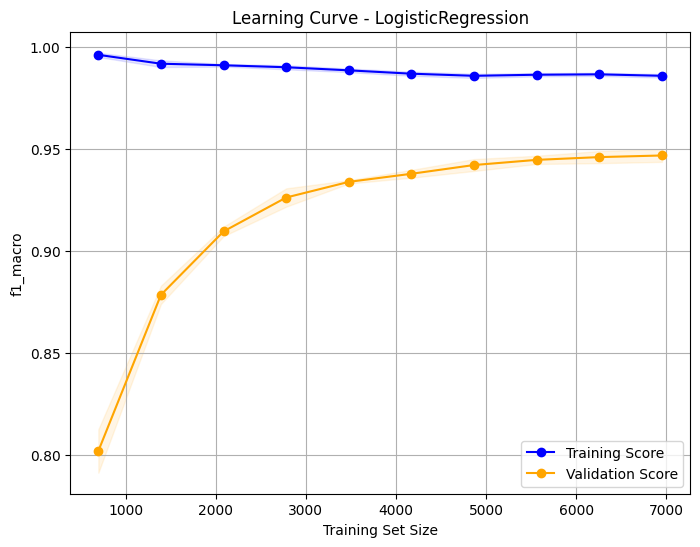


Running model: RidgeClassifier


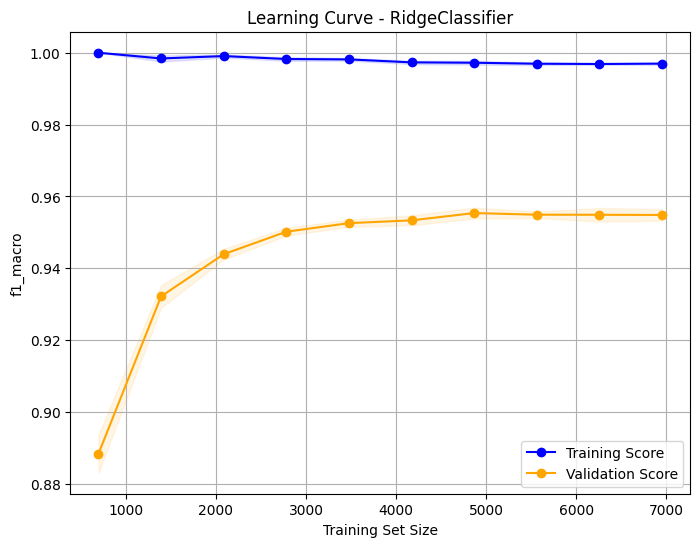


Running model: SGDClassifier


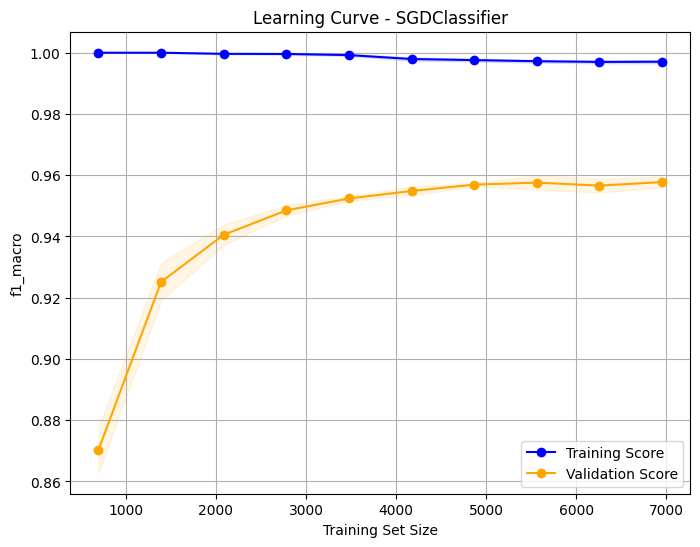


Running model: PassiveAggressive


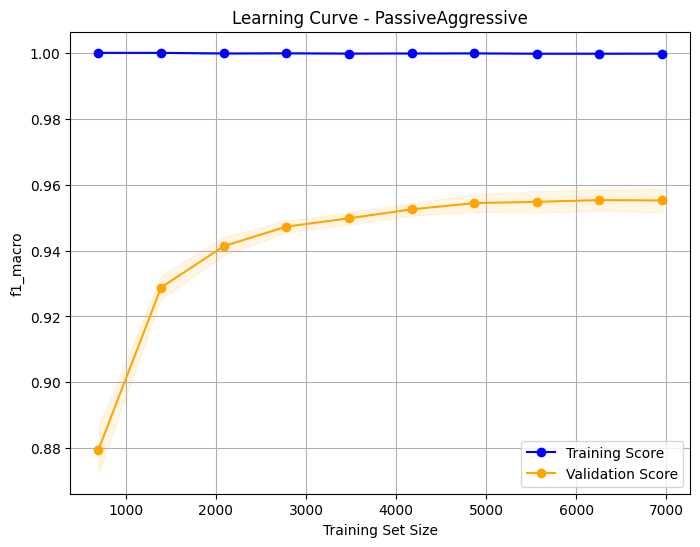


Running model: MultinomialNB


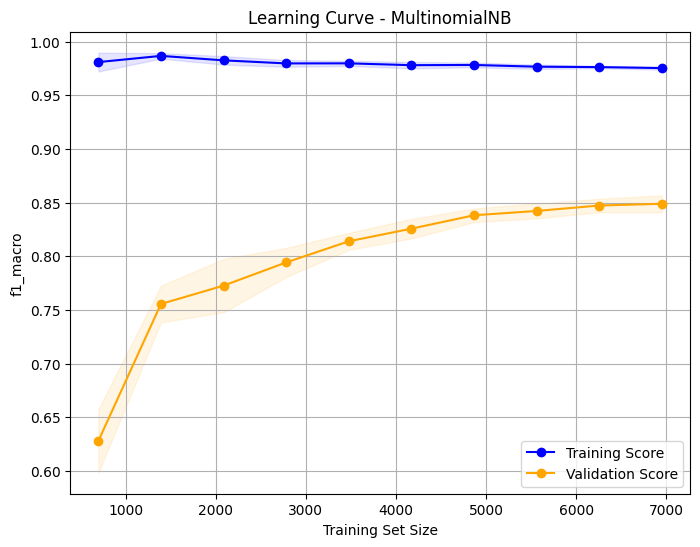


Running model: ComplementNB


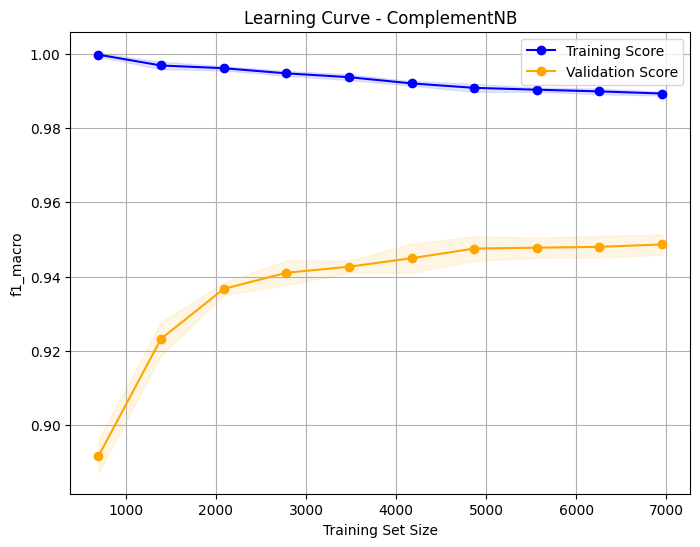


Running model: KNN


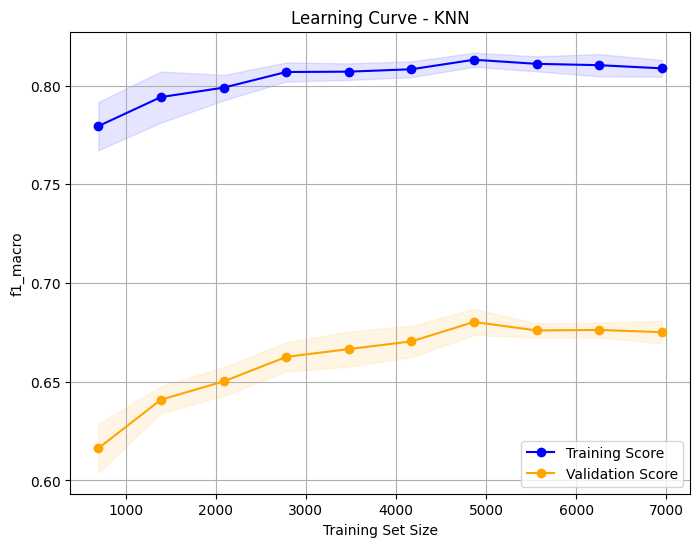


Running model: DecisionTree


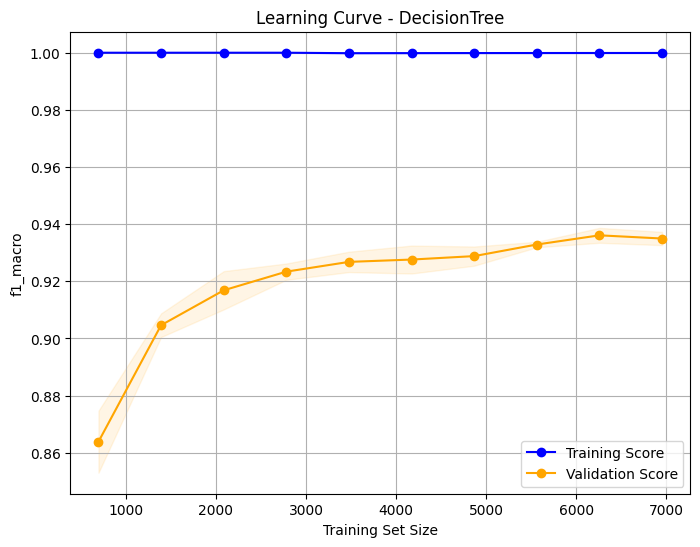


Running model: LinearSVC


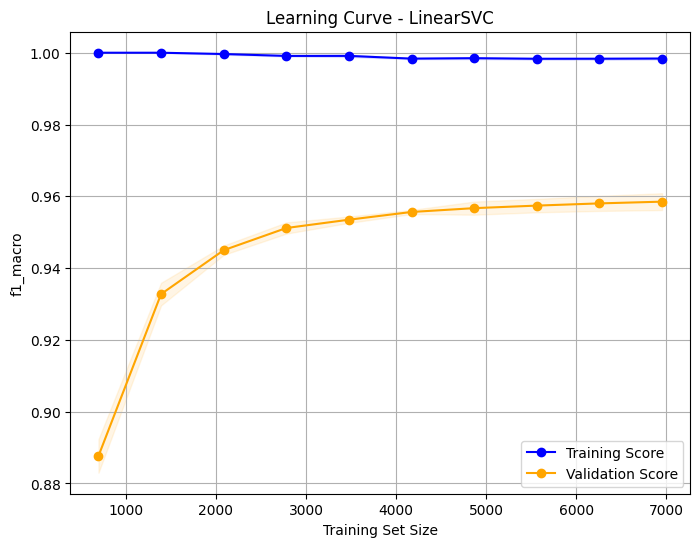


Running model: SVC


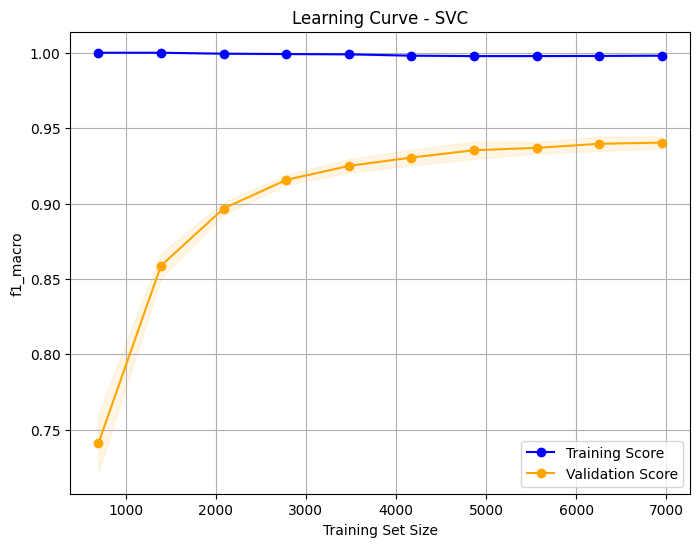


Running model: RandomForest


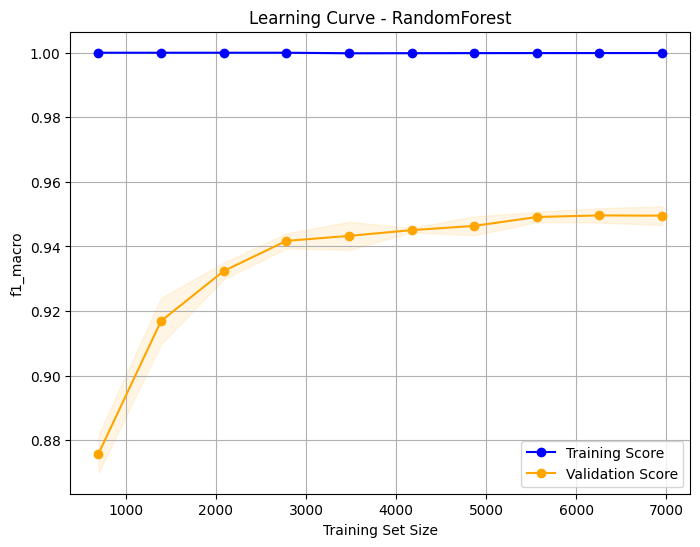


Running model: XGBClassifier


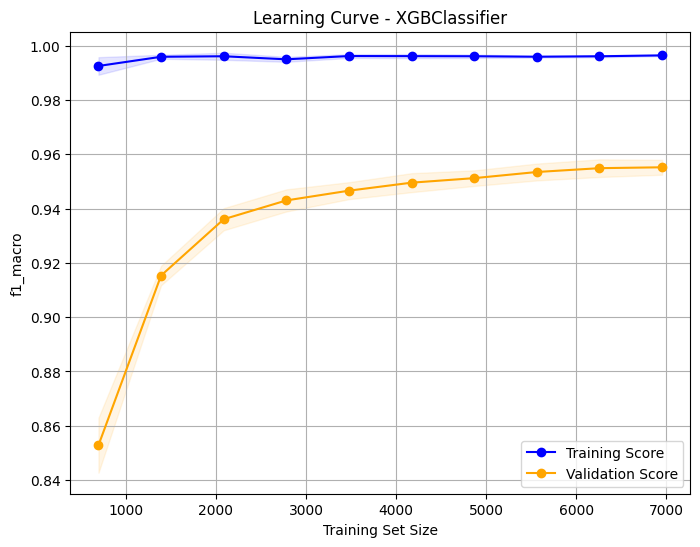

Best model: LinearSVC


In [ ]:
models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("model", model)
    ])

    cv_res = avaliar_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plotar_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [7]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/baseline/baseline_03_TweetEmotionsPTBR_TFIDF.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro
LogisticRegression,0.9464 ± 0.0053,0.9483 ± 0.005,0.9468 ± 0.0053,0.9471 ± 0.0052
RidgeClassifier,0.9557 ± 0.0048,0.9566 ± 0.0047,0.9561 ± 0.0048,0.9561 ± 0.0048
SGDClassifier,0.9575 ± 0.0045,0.9583 ± 0.0042,0.9579 ± 0.0044,0.9578 ± 0.0044
PassiveAggressive,0.955 ± 0.0039,0.9558 ± 0.0037,0.9555 ± 0.0038,0.9554 ± 0.0038
MultinomialNB,0.846 ± 0.0098,0.8709 ± 0.0086,0.8447 ± 0.0098,0.849 ± 0.0095
ComplementNB,0.9496 ± 0.0042,0.9504 ± 0.0041,0.9501 ± 0.0041,0.9498 ± 0.0041
KNN,0.6769 ± 0.0121,0.7103 ± 0.0111,0.6785 ± 0.0122,0.6774 ± 0.0125
DecisionTree,0.9349 ± 0.0057,0.9374 ± 0.0056,0.9355 ± 0.0057,0.9359 ± 0.0056
LinearSVC,0.9583 ± 0.0046,0.9593 ± 0.0045,0.9587 ± 0.0046,0.9588 ± 0.0045
SVC,0.9412 ± 0.0056,0.9445 ± 0.0051,0.9415 ± 0.0056,0.9422 ± 0.0054


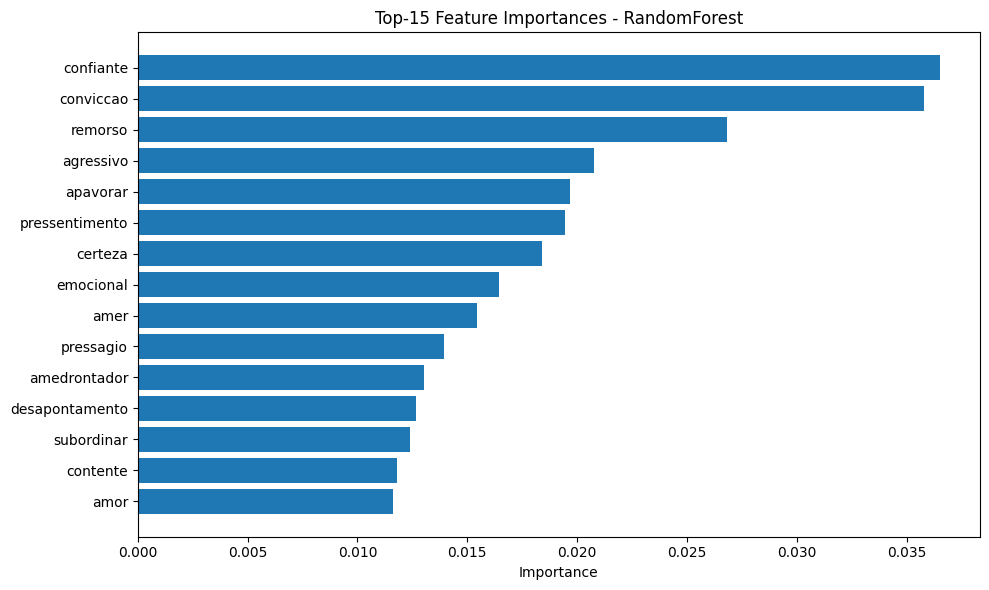

In [8]:
pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["tfidf"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")